In [3]:
import pandas as pd
import numpy as np

In [4]:
import json
import numpy as np
import pandas as pd

FILE_PATH = "../data/raw/ember2018/train_features_1.jsonl"

MAX_SAMPLES = 30000

records = []
labels = []

with open(FILE_PATH, "r", encoding="utf-8") as f:

    for line in f:

        record = json.loads(line)

        label = record.get("label")

        # Only labeled samples
        if label not in [0, 1]:
            continue

        records.append(record)
        labels.append(label)

        if len(records) >= MAX_SAMPLES:
            break

print("Samples loaded:", len(records))
print("Labels:", len(labels))

Samples loaded: 30000
Labels: 30000


In [5]:
print(records[0].keys())

dict_keys(['sha256', 'md5', 'appeared', 'label', 'avclass', 'histogram', 'byteentropy', 'strings', 'general', 'header', 'section', 'imports', 'exports', 'datadirectories'])


In [6]:
for key, value in records[0].items():
    print(
        key,
        "->",
        type(value).__name__
    )

sha256 -> str
md5 -> str
appeared -> str
label -> int
avclass -> str
histogram -> list
byteentropy -> list
strings -> dict
general -> dict
header -> dict
section -> dict
imports -> dict
exports -> list
datadirectories -> list


In [7]:
def compact_features(record):

    features = {}

    # =====================================
    # Appeared
    # =====================================

    appeared = record.get("appeared", 0)

    # EMBER may store this as YYYY-MM
    if isinstance(appeared, str):

        try:
            date = pd.to_datetime(appeared)

            features["appeared_year"] = date.year
            features["appeared_month"] = date.month

        except:
            features["appeared_year"] = 0
            features["appeared_month"] = 0

    elif isinstance(appeared, (int, float)):

        features["appeared_year"] = float(appeared)
        features["appeared_month"] = 0

    else:

        features["appeared_year"] = 0
        features["appeared_month"] = 0


    # =====================================
    # Histogram
    # =====================================

    histogram = record.get("histogram", [])

    if isinstance(histogram, list) and len(histogram) > 0:

        histogram = np.asarray(
            histogram,
            dtype=np.float32
        )

        features["hist_mean"] = float(histogram.mean())
        features["hist_std"] = float(histogram.std())
        features["hist_min"] = float(histogram.min())
        features["hist_max"] = float(histogram.max())
        features["hist_sum"] = float(histogram.sum())

    else:

        features["hist_mean"] = 0
        features["hist_std"] = 0
        features["hist_min"] = 0
        features["hist_max"] = 0
        features["hist_sum"] = 0


    # =====================================
    # Byte Entropy
    # =====================================

    entropy = record.get("byteentropy", [])

    if isinstance(entropy, list) and len(entropy) > 0:

        entropy = np.asarray(
            entropy,
            dtype=np.float32
        )

        features["entropy_mean"] = float(entropy.mean())
        features["entropy_std"] = float(entropy.std())
        features["entropy_min"] = float(entropy.min())
        features["entropy_max"] = float(entropy.max())

    else:

        features["entropy_mean"] = 0
        features["entropy_std"] = 0
        features["entropy_min"] = 0
        features["entropy_max"] = 0


    # =====================================
    # Strings
    # =====================================

    strings = record.get("strings", {})

    if isinstance(strings, dict):

        for key, value in strings.items():

            if isinstance(value, (int, float, np.number)):

                features[f"strings_{key}"] = float(value)


    # =====================================
    # General
    # =====================================

    general = record.get("general", {})

    if isinstance(general, dict):

        for key, value in general.items():

            if isinstance(value, (int, float, np.number)):

                features[f"general_{key}"] = float(value)


    # =====================================
    # Header
    # =====================================

    header = record.get("header", {})

    if isinstance(header, dict):

        for key, value in header.items():

            if isinstance(value, (int, float, np.number)):

                features[f"header_{key}"] = float(value)


    # =====================================
    # Section
    # =====================================

    section = record.get("section", {})

    if isinstance(section, dict):

        for key, value in section.items():

            if isinstance(value, (int, float, np.number)):

                features[f"section_{key}"] = float(value)

            elif isinstance(value, list):

                features[f"section_{key}_count"] = float(len(value))


    # =====================================
    # Imports
    # =====================================

    imports = record.get("imports", {})

    if isinstance(imports, dict):

        features["imports_count"] = float(len(imports))

        total_imports = 0

        for value in imports.values():

            if isinstance(value, list):

                total_imports += len(value)

        features["total_imported_functions"] = float(total_imports)

    elif isinstance(imports, list):

        features["imports_count"] = float(len(imports))
        features["total_imported_functions"] = float(len(imports))


    # =====================================
    # Exports
    # =====================================

    exports = record.get("exports", [])

    if isinstance(exports, list):

        features["exports_count"] = float(len(exports))

    elif isinstance(exports, dict):

        features["exports_count"] = float(len(exports))


    # =====================================
    # Data Directories
    # =====================================

    directories = record.get(
        "datadirectories",
        []
    )

    if isinstance(directories, list):

        features["datadirectories_count"] = float(
            len(directories)
        )

    elif isinstance(directories, dict):

        features["datadirectories_count"] = float(
            len(directories)
        )


    return features

In [8]:
test = compact_features(records[0])

print("Number of features:", len(test))

print("\nFeatures:")

for key, value in test.items():
    print(key, "=", value)

Number of features: 34

Features:
appeared_year = 2018
appeared_month = 1
hist_mean = 1366.44921875
hist_std = 3836.751220703125
hist_min = 515.0
hist_max = 60782.0
hist_sum = 349811.0
entropy_mean = 2720.0
entropy_std = 4880.4931640625
entropy_min = 0.0
entropy_max = 29295.0
strings_numstrings = 3863.0
strings_avlength = 17.643541289153507
strings_printables = 68157.0
strings_entropy = 5.683163905800377
strings_paths = 6.0
strings_urls = 22.0
strings_registry = 0.0
strings_MZ = 7.0
general_size = 349811.0
general_vsize = 28672.0
general_has_debug = 0.0
general_exports = 0.0
general_imports = 55.0
general_has_relocations = 0.0
general_has_resources = 1.0
general_has_signature = 0.0
general_has_tls = 0.0
general_symbols = 0.0
section_sections_count = 5.0
imports_count = 6.0
total_imported_functions = 55.0
exports_count = 0.0
datadirectories_count = 15.0


In [9]:
feature_records = []

for i, record in enumerate(records):

    feature_records.append(
        compact_features(record)
    )

    if (i + 1) % 5000 == 0:
        print(f"Processed {i + 1:,} samples")

Processed 5,000 samples
Processed 10,000 samples
Processed 15,000 samples
Processed 20,000 samples
Processed 25,000 samples
Processed 30,000 samples


In [10]:
string_features = []

for i, record in enumerate(feature_records):

    for key, value in record.items():

        if isinstance(value, str):

            string_features.append(
                (i, key, value)
            )

print("String values found:", len(string_features))

if string_features:
    print(string_features[:10])

String values found: 0


In [11]:
X = pd.DataFrame(feature_records)

X = X.astype(np.float32)

y = pd.Series(
    labels,
    name="label",
    dtype=np.int8
)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (30000, 34)
Target shape: (30000,)


In [12]:
print(
    "X memory usage:",
    round(
        X.memory_usage(deep=True).sum() / (1024 ** 2),
        2
    ),
    "MB"
)

X memory usage: 3.89 MB


In [13]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

In [14]:
print("Missing values:", X.isnull().sum().sum())
print("Infinite values:", np.isinf(X.to_numpy()).sum())

Missing values: 0
Infinite values: 0


In [15]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("X memory usage:", round(X.memory_usage(deep=True).sum() / (1024 ** 2), 2), "MB")

Feature matrix shape: (30000, 34)
Target shape: (30000,)
X memory usage: 3.89 MB


In [16]:
print("Label distribution:")
print(y.value_counts())

print("\nLabel percentages:")
print(y.value_counts(normalize=True) * 100)

Label distribution:
label
1    15862
0    14138
Name: count, dtype: int64

Label percentages:
label
1    52.873333
0    47.126667
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (24000, 34)
Testing samples: (6000, 34)


In [18]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training model...")

model.fit(X_train, y_train)

print("Training completed!")

Training model...
Training completed!


In [19]:
y_pred = model.predict(X_test)

print("Predictions generated!")
print(y_pred[:20])

Predictions generated!
[1 1 1 0 0 0 0 0 1 1 0 1 0 1 0 1 0 0 1 1]


In [20]:
y_probability = model.predict_proba(X_test)[:, 1]

print("Malware probabilities:")
print(y_probability[:20])

Malware probabilities:
[1.    1.    0.89  0.18  0.    0.295 0.32  0.11  1.    1.    0.01  1.
 0.03  1.    0.    1.    0.05  0.025 1.    1.   ]


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.935
Precision: 0.9624
Recall   : 0.9127
F1 Score : 0.9369

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      2828
           1       0.96      0.91      0.94      3172

    accuracy                           0.94      6000
   macro avg       0.93      0.94      0.93      6000
weighted avg       0.94      0.94      0.94      6000



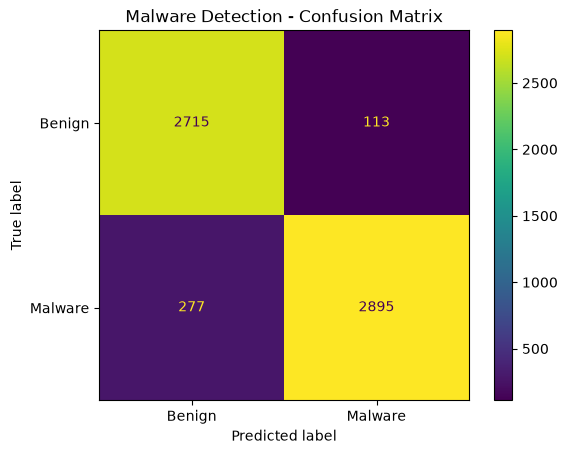

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Benign", "Malware"]
)

plt.title("Malware Detection - Confusion Matrix")
plt.show()

In [23]:
risk_score = y_probability * 100

In [24]:
def get_risk_level(score):

    if score < 30:
        return "LOW"

    elif score < 70:
        return "MEDIUM"

    else:
        return "HIGH"

In [25]:
risk_levels = [
    get_risk_level(score)
    for score in risk_score
]

In [26]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Prediction": y_pred,
    "Malware_Probability": y_probability,
    "Risk_Score": risk_score,
    "Risk_Level": risk_levels
})

print(results.head(20))

    Actual  Prediction  Malware_Probability  Risk_Score Risk_Level
0        1           1                1.000       100.0       HIGH
1        1           1                1.000       100.0       HIGH
2        1           1                0.890        89.0       HIGH
3        0           0                0.180        18.0        LOW
4        0           0                0.000         0.0        LOW
5        0           0                0.295        29.5        LOW
6        1           0                0.320        32.0     MEDIUM
7        0           0                0.110        11.0        LOW
8        1           1                1.000       100.0       HIGH
9        1           1                1.000       100.0       HIGH
10       0           0                0.010         1.0        LOW
11       1           1                1.000       100.0       HIGH
12       0           0                0.030         3.0        LOW
13       1           1                1.000       100.0       

In [27]:
from pathlib import Path

Path("../reports").mkdir(
    parents=True,
    exist_ok=True
)

print("Reports folder is ready.")

Reports folder is ready.


In [28]:
results.to_csv(
    "../reports/model_results_baseline.csv",
    index=False
)

print("Baseline results saved!")

Baseline results saved!


In [29]:
import pandas as pd

baseline_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

baseline_metrics.to_csv(
    "../reports/baseline_metrics.csv",
    index=False
)

print("Baseline metrics saved successfully!")
print(baseline_metrics)

Baseline metrics saved successfully!
      Metric     Score
0   Accuracy  0.935000
1  Precision  0.962434
2     Recall  0.912673
3   F1 Score  0.936893


In [30]:
from pathlib import Path

processed_dir = Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

X_train.to_csv(processed_dir / "X_train.csv", index=False)
X_test.to_csv(processed_dir / "X_test.csv", index=False)

y_train.to_csv(processed_dir / "y_train.csv", index=False)
y_test.to_csv(processed_dir / "y_test.csv", index=False)

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


In [31]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (24000, 34)
X_test : (6000, 34)
y_train: (24000,)
y_test : (6000,)


In [32]:
print(type(X))
print(X.shape)
print(X[:2])

<class 'pandas.DataFrame'>
(30000, 34)
   appeared_year  appeared_month    hist_mean     hist_std  hist_min  \
0         2018.0             1.0  1366.449219  3836.751221     515.0   
1         2018.0             1.0   630.000000  2306.250977      32.0   

   hist_max  hist_sum  entropy_mean  entropy_std  entropy_min  ...  \
0   60782.0  349811.0        2720.0  4880.493164          0.0  ...   
1   35534.0  161280.0        1248.0  3143.090088          0.0  ...   

   general_has_relocations  general_has_resources  general_has_signature  \
0                      0.0                    1.0                    0.0   
1                      1.0                    1.0                    0.0   

   general_has_tls  general_symbols  section_sections_count  imports_count  \
0              0.0              0.0                     5.0            6.0   
1              0.0              0.0                     5.0            8.0   

   total_imported_functions  exports_count  datadirectories_count  
0

In [33]:
selected_features = [
    'imports_count',
    'strings_avlength',
    'total_imported_functions',
    'strings_entropy',
    'hist_min',
    'general_imports',
    'entropy_max',
    'general_vsize',
    'general_has_tls',
    'strings_MZ',
    'entropy_std',
    'strings_urls',
    'hist_std',
    'strings_printables',
    'hist_max',
    'strings_numstrings',
    'general_size',
    'hist_sum',
    'hist_mean',
    'entropy_mean',
    'general_has_debug',
    'section_sections_count',
    'strings_paths',
    'general_has_signature',
    'general_exports'
]

feature_stats = X[selected_features].describe().T[
    ['min', 'max', 'mean', 'std']
]

print(feature_stats)

                                 min           max          mean           std
imports_count               0.000000  8.500000e+01  6.482934e+00  5.701602e+00
strings_avlength            0.000000  3.534842e+04  3.696619e+01  3.367750e+02
total_imported_functions    0.000000  1.534100e+04  1.190078e+02  2.217547e+02
strings_entropy             0.000000  6.584948e+00  5.854507e+00  6.020619e-01
hist_min                    0.000000  8.356310e+05  3.068472e+03  1.682165e+04
general_imports             0.000000  1.391100e+04  1.125454e+02  2.017255e+02
entropy_max               229.000000  9.988666e+07  4.233132e+05  1.405761e+06
general_vsize             512.000000  7.716372e+08  2.355395e+06  9.478979e+06
general_has_tls             0.000000  1.000000e+00  3.510000e-01  4.772909e-01
strings_MZ                  1.000000  3.467000e+03  1.878530e+01  7.453367e+01
entropy_std                14.352307  6.724350e+06  5.038939e+04  1.607994e+05
strings_urls                0.000000  3.031000e+03  

In [34]:
percentiles = X[selected_features].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
).T[
    ['min', '1%', '25%', '50%', '75%', '99%', 'max']
]

print(percentiles)

                                 min            1%            25%  \
imports_count               0.000000      0.000000       1.000000   
strings_avlength            0.000000      5.649347       7.682350   
total_imported_functions    0.000000      0.000000       8.000000   
strings_entropy             0.000000      3.963066       5.493906   
hist_min                    0.000000      0.000000      57.000000   
general_imports             0.000000      0.000000       8.000000   
entropy_max               229.000000   1474.000000   31172.750000   
general_vsize             512.000000  16384.000000  159744.000000   
general_has_tls             0.000000      0.000000       0.000000   
strings_MZ                  1.000000      1.000000       2.000000   
entropy_std                14.352307    157.029598    3625.444214   
strings_urls                0.000000      0.000000       0.000000   
hist_std                   12.864242    130.850673    1399.132446   
strings_printables          0.0000

In [35]:
calc_features = {
    'imports_count': 7,
    'strings_avlength': 17.138462,
    'total_imported_functions': 33,
    'strings_entropy': 5.307810,
    'hist_min': 0,
    'general_imports': 33,
    'entropy_max': 11382,
    'general_vsize': 45056,
    'general_has_tls': 0,
    'strings_MZ': 4,
    'entropy_std': 908.248834,
    'strings_urls': 1,
    'hist_std': 700.142614,
    'strings_printables': 2228,
    'hist_max': 7338,
    'strings_numstrings': 130,
    'general_size': 27648,
    'hist_sum': 27648,
    'hist_mean': 108,
    'entropy_mean': 208,
    'general_has_debug': 1,
    'section_sections_count': 6,
    'strings_paths': 0,
    'general_has_signature': 0,
    'general_exports': 0
}

comparison = pd.DataFrame({
    "calc.exe": pd.Series(calc_features),
    "training_median": X[selected_features].median(),
    "training_25th": X[selected_features].quantile(0.25),
    "training_75th": X[selected_features].quantile(0.75)
})

comparison

,calc.exe,training_median,training_25th,training_75th
imports_count,7.000000,6.000000,1.000000,1.000000e+01
strings_avlength,17.138462,11.991822,7.682350,1.804474e+01
total_imported_functions,33.000000,69.000000,8.000000,1.690000e+02
strings_entropy,5.307810,5.846133,5.493906,6.404627e+00
hist_min,0.000000,375.000000,57.000000,1.944000e+03
general_imports,33.000000,64.000000,8.000000,1.650000e+02
entropy_max,11382.000000,107773.000000,31172.750000,4.708552e+05
general_vsize,45056.000000,589824.000000,159744.000000,1.810432e+06
general_has_tls,0.000000,0.000000,0.000000,1.000000e+00
strings_MZ,4.000000,5.000000,2.000000,1.200000e+01


In [36]:
import joblib

binary_model = joblib.load("../models/final_malware_rf.pkl")

print(type(binary_model))
print("Model loaded successfully.")

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Model loaded successfully.


In [37]:
importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": binary_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.to_string(index=False))

                 feature  importance
           imports_count    0.069600
                hist_min    0.062347
        strings_avlength    0.060206
         strings_entropy    0.056893
total_imported_functions    0.053311
              strings_MZ    0.049795
         general_imports    0.049170
             entropy_max    0.045818
           general_vsize    0.045647
         general_has_tls    0.045404
            strings_urls    0.041339
                hist_std    0.038515
             entropy_std    0.038515
      strings_printables    0.035599
      strings_numstrings    0.034010
                hist_max    0.033793
               hist_mean    0.031833
            general_size    0.031189
                hist_sum    0.029194
  section_sections_count    0.029160
       general_has_debug    0.028366
            entropy_mean    0.027820
           strings_paths    0.022889
   general_has_signature    0.019794
         general_exports    0.019794


In [38]:
calc_df = pd.DataFrame([calc_features])[selected_features]

tree_predictions = binary_model.predict(calc_df)

print("Number of trees:", len(tree_predictions))
print("Benign votes:", (tree_predictions == 0).sum())
print("Malware votes:", (tree_predictions == 1).sum())
print("Malware vote percentage:",
      (tree_predictions == 1).mean())

Number of trees: 1
Benign votes: 0
Malware votes: 1
Malware vote percentage: 1.0


In [39]:
print("Model probability:",
      binary_model.predict_proba(calc_df)[0])

Model probability: [0.364 0.636]


In [40]:
tree_votes = np.array([
    tree.predict(calc_df.values)[0]
    for tree in binary_model.estimators_
])

print("Number of trees:", len(tree_votes))
print("Benign votes:", (tree_votes == 0).sum())
print("Malware votes:", (tree_votes == 1).sum())
print("Malware vote percentage:", tree_votes.mean())

Number of trees: 250
Benign votes: 91
Malware votes: 159
Malware vote percentage: 0.636


In [41]:
import sys
sys.path.append("..")

from inference import predict_from_file

print("Inference function loaded successfully.")

Inference function loaded successfully.


In [42]:
from pathlib import Path

test_files = [
    r"C:\Windows\System32\notepad.exe",
    r"C:\Windows\System32\calc.exe",
    r"C:\Windows\System32\mspaint.exe",
    r"C:\Windows\System32\write.exe",
    r"C:\Windows\System32\cmd.exe",
]

for file_path in test_files:
    try:
        result = predict_from_file(file_path)
        print(
            Path(file_path).name,
            "->",
            result["prediction"],
            "| probability:",
            result["malware_probability"],
            "| risk:",
            result["risk_level"]
        )
    except Exception as e:
        print(Path(file_path).name, "-> ERROR:", e)

notepad.exe -> Benign | probability: 0.44 | risk: Medium
calc.exe -> Malware | probability: 0.636 | risk: Medium
mspaint.exe -> Benign | probability: 0.18 | risk: Low
write.exe -> Benign | probability: 0.096 | risk: Low
cmd.exe -> Benign | probability: 0.232 | risk: Low


In [43]:
calc_df = pd.DataFrame([calc_features])[selected_features]

comparison = pd.DataFrame({
    "calc.exe": calc_df.iloc[0],
    "training_median": X[selected_features].median(),
    "training_25%": X[selected_features].quantile(0.25),
    "training_75%": X[selected_features].quantile(0.75)
})

comparison["relative_to_median"] = (
    comparison["calc.exe"] / comparison["training_median"]
)

comparison

,calc.exe,training_median,training_25%,training_75%,relative_to_median
imports_count,7.000000,6.000000,1.000000,1.000000e+01,1.166667
strings_avlength,17.138462,11.991822,7.682350,1.804474e+01,1.429179
total_imported_functions,33.000000,69.000000,8.000000,1.690000e+02,0.478261
strings_entropy,5.307810,5.846133,5.493906,6.404627e+00,0.907918
hist_min,0.000000,375.000000,57.000000,1.944000e+03,0.000000
general_imports,33.000000,64.000000,8.000000,1.650000e+02,0.515625
entropy_max,11382.000000,107773.000000,31172.750000,4.708552e+05,0.105611
general_vsize,45056.000000,589824.000000,159744.000000,1.810432e+06,0.076389
general_has_tls,0.000000,0.000000,0.000000,1.000000e+00,NaN
strings_MZ,4.000000,5.000000,2.000000,1.200000e+01,0.800000


In [44]:
import numpy as np
import pandas as pd

calc_input = calc_df.values

feature_names = selected_features

feature_effects = []

for tree in binary_model.estimators_:
    tree_model = tree.tree_

    for node in range(tree_model.node_count):
        feature_index = tree_model.feature[node]

        if feature_index >= 0:
            threshold = tree_model.threshold[node]
            feature_name = feature_names[feature_index]

            calc_value = calc_input[0, feature_index]

            if calc_value <= threshold:
                direction = "Left"
            else:
                direction = "Right"

            feature_effects.append({
                "feature": feature_name,
                "calc_value": calc_value,
                "threshold": threshold,
                "direction": direction
            })

feature_effects_df = pd.DataFrame(feature_effects)

feature_effects_df.head(20)

,feature,calc_value,threshold,direction
0,general_size,27648.000000,1.130014e+06,Left
1,general_has_debug,1.000000,5.000000e-01,Right
2,hist_mean,108.000000,1.778711e+02,Left
3,general_imports,33.000000,1.500000e+00,Right
4,strings_entropy,5.307810,6.170649e+00,Left
5,hist_std,700.142614,4.479410e+02,Right
6,general_vsize,45056.000000,3.727360e+05,Left
7,hist_mean,108.000000,4.431250e+01,Right
8,hist_max,7338.000000,2.431000e+03,Right
9,entropy_mean,208.000000,2.000000e+01,Right


In [45]:
from collections import Counter
import numpy as np
import pandas as pd

malware_trees = []
benign_trees = []

for tree in binary_model.estimators_:
    prediction = tree.predict(calc_df.values)[0]

    if prediction == 1:
        malware_trees.append(tree)
    else:
        benign_trees.append(tree)

def get_used_features(trees):
    counter = Counter()

    for tree in trees:
        for feature_index in tree.tree_.feature:
            if feature_index >= 0:
                counter[selected_features[feature_index]] += 1

    return counter

malware_feature_usage = get_used_features(malware_trees)
benign_feature_usage = get_used_features(benign_trees)

comparison = pd.DataFrame({
    "malware_tree_usage": malware_feature_usage,
    "benign_tree_usage": benign_feature_usage
}).fillna(0)

comparison["difference"] = (
    comparison["malware_tree_usage"]
    - comparison["benign_tree_usage"]
)

comparison.sort_values(
    "difference",
    ascending=False
)

,malware_tree_usage,benign_tree_usage,difference
strings_entropy,14786,8379,6407
strings_avlength,14859,8578,6281
hist_max,13741,7804,5937
hist_std,13761,7835,5926
hist_min,13621,7741,5880
general_vsize,13595,7844,5751
strings_printables,13654,7991,5663
entropy_max,13102,7718,5384
entropy_std,12700,7321,5379
strings_numstrings,13088,7747,5341


In [46]:
test_files = [
    r"C:\Windows\System32\notepad.exe",
    r"C:\Windows\System32\calc.exe",
    r"C:\Windows\System32\mspaint.exe",
    r"C:\Windows\System32\write.exe",
    r"C:\Windows\System32\cmd.exe",
    r"C:\Windows\System32\conhost.exe",
    r"C:\Windows\System32\reg.exe",
    r"C:\Windows\System32\find.exe",
    r"C:\Windows\System32\hostname.exe",
    r"C:\Windows\System32\where.exe",
]

results = []

for file_path in test_files:
    try:
        result = predict_from_file(file_path)

        results.append({
            "file": Path(file_path).name,
            "prediction": result["prediction"],
            "malware_probability": result["malware_probability"],
            "risk": result["risk_level"]
        })

    except Exception as e:
        results.append({
            "file": Path(file_path).name,
            "prediction": "ERROR",
            "malware_probability": None,
            "risk": str(e)
        })

pd.DataFrame(results)

,file,prediction,malware_probability,risk
0,notepad.exe,Benign,0.440,Medium
1,calc.exe,Malware,0.636,Medium
2,mspaint.exe,Benign,0.180,Low
3,write.exe,Benign,0.096,Low
4,cmd.exe,Benign,0.232,Low
5,conhost.exe,Benign,0.288,Low
6,reg.exe,Benign,0.288,Low
7,find.exe,Benign,0.100,Low
8,hostname.exe,Benign,0.100,Low
9,where.exe,Benign,0.284,Low


In [47]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parents[1]))

In [48]:
from pathlib import Path

print(Path.cwd())

c:\Users\DELL\Desktop\Springboard\Malware-Classification-System\ml-engine\notebooks


In [49]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\DELL\Desktop\Springboard\Malware-Classification-System\ml-engine")

sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)
print((PROJECT_ROOT / "feature_extractor.py").exists())

C:\Users\DELL\Desktop\Springboard\Malware-Classification-System\ml-engine
True


In [107]:
import importlib
import feature_extractor

importlib.reload(feature_extractor)

print("feature_extractor loaded successfully")

feature_extractor loaded successfully


In [51]:
hasattr(feature_extractor, "extract_metadata_features")

True

In [52]:
from feature_extractor import parse_pe_file

file_path = r"C:\Windows\System32\notepad.exe"

binary = parse_pe_file(file_path)

with open(file_path, "rb") as f:
    raw_data = f.read()

metadata = feature_extractor.extract_metadata_features(
    binary,
    raw_data
)

metadata

{'file_size': 200704,
 'virtual_size': 229376,
 'sections_count': 7,
 'imports_count': 28,
 'imported_functions': 260,
 'exports_count': 0,
 'has_debug': 1,
 'has_signature': 0,
 'has_tls': 0}

In [93]:
import importlib
import feature_extractor

importlib.reload(feature_extractor)

<module 'feature_extractor' from 'C:\\Users\\DELL\\Desktop\\Springboard\\Malware-Classification-System\\ml-engine\\feature_extractor.py'>

In [94]:
hasattr(feature_extractor, "extract_suspicious_indicators")

True

In [55]:
file_path = r"C:\Windows\System32\notepad.exe"

with open(file_path, "rb") as f:
    raw_data = f.read()

indicators = feature_extractor.extract_suspicious_indicators(raw_data)

indicators

{'urls': [], 'ip_addresses': [], 'powershell_commands': [], 'file_paths': []}

In [56]:
hasattr(feature_extractor, "extract_api_indicators")

True

In [57]:
hasattr(feature_extractor, "extract_api_indicators")

True

In [58]:
file_path = r"C:\Windows\System32\notepad.exe"

binary = feature_extractor.parse_pe_file(file_path)

api_indicators = feature_extractor.extract_api_indicators(binary)

api_indicators["suspicious_apis"]

{}

In [59]:
len(api_indicators["imported_apis"])

258

In [60]:
api_indicators["suspicious_apis"]

{}

In [62]:
hasattr(feature_extractor, "run_static_analysis")

True

In [63]:
file_path = r"C:\Windows\System32\notepad.exe"

static_report = feature_extractor.run_static_analysis(
    file_path
)

static_report

{'file_type': 'Windows PE',
 'hashes': {'md5': '6f51bcabf1b2b34ad7e670aee6da451f',
  'sha256': 'da5807bb0997cc6b5132950ec87eda2b33b1ac4533cf1f7a22a6f3b576ed7c5b'},
 'metadata': {'file_size': 200704,
  'virtual_size': 229376,
  'sections_count': 7,
  'imports_count': 28,
  'imported_functions': 260,
  'exports_count': 0,
  'has_debug': 1,
  'has_signature': 0,
  'has_tls': 0},
 'string_features': {'strings_avlength': 11.776645041705283,
  'strings_entropy': 5.635082721710205,
  'strings_MZ': 7,
  'strings_urls': 1,
  'strings_printables': 12707,
  'strings_numstrings': 1079,
  'strings_paths': 0},
 'suspicious_indicators': {'urls': [],
  'ip_addresses': [],
  'powershell_commands': [],
  'file_paths': []},
 'api_analysis': {'imported_apis': ['AbortDoc',
   'AcquireSRWLockExclusive',
   'AcquireSRWLockShared',
   'CharNextW',
   'CharUpperW',
   'CheckMenuItem',
   'CloseClipboard',
   'CloseHandle',
   'CloseThreadpoolTimer',
   'CoCreateFreeThreadedMarshaler',
   'CoCreateGuid',
   'Co

In [64]:
print("FILE TYPE:")
print(static_report["file_type"])

print("\nHASHES:")
print(static_report["hashes"])

print("\nMETADATA:")
print(static_report["metadata"])

print("\nSUSPICIOUS INDICATORS:")
print(static_report["suspicious_indicators"])

print("\nSUSPICIOUS APIs:")
print(static_report["api_analysis"]["suspicious_apis"])

FILE TYPE:
Windows PE

HASHES:
{'md5': '6f51bcabf1b2b34ad7e670aee6da451f', 'sha256': 'da5807bb0997cc6b5132950ec87eda2b33b1ac4533cf1f7a22a6f3b576ed7c5b'}

METADATA:
{'file_size': 200704, 'virtual_size': 229376, 'sections_count': 7, 'imports_count': 28, 'imported_functions': 260, 'exports_count': 0, 'has_debug': 1, 'has_signature': 0, 'has_tls': 0}

SUSPICIOUS INDICATORS:
{'urls': [], 'ip_addresses': [], 'powershell_commands': [], 'file_paths': []}

SUSPICIOUS APIs:
{}


In [68]:
static_report = feature_extractor.run_static_analysis(
    r"C:\Windows\System32\notepad.exe"
)

static_report["yara_matches"]

[]

In [71]:
yara_results = feature_extractor.run_yara_scan(
    r"C:\Windows\System32\notepad.exe"
)

yara_results


[]

In [72]:
static_report = feature_extractor.run_static_analysis(
    r"C:\Windows\System32\notepad.exe"
)

static_report.keys()

dict_keys(['file_type', 'hashes', 'metadata', 'string_features', 'suspicious_indicators', 'api_analysis', 'yara_matches'])

In [73]:
static_report["yara_matches"]

[]

In [76]:
report = feature_extractor.generate_static_report(
    r"C:\Windows\System32\notepad.exe"
)

In [77]:
report.keys()

dict_keys(['file', 'metadata', 'strings', 'suspicious_indicators', 'api_analysis', 'yara_findings'])

In [78]:
report["file"]

{'type': 'Windows PE',
 'hashes': {'md5': '6f51bcabf1b2b34ad7e670aee6da451f',
  'sha256': 'da5807bb0997cc6b5132950ec87eda2b33b1ac4533cf1f7a22a6f3b576ed7c5b'}}

In [79]:
report["yara_findings"]

[]

In [83]:
import importlib
import inference

inference = importlib.reload(inference)

print(hasattr(inference, "generate_security_report"))

True


In [84]:
import inference

security_report = inference.generate_security_report(
    r"C:\Windows\System32\notepad.exe"
)

In [85]:
security_report.keys()

dict_keys(['file', 'metadata', 'strings', 'suspicious_indicators', 'api_analysis', 'yara_findings', 'ml_classification'])

In [86]:
security_report["ml_classification"]

{'prediction': 'Benign',
 'malware_probability': 0.44,
 'risk_level': 'Medium',
 'malware_family': None,
 'family_probability': None}

In [87]:
security_report = inference.generate_security_report(
    r"C:\Windows\System32\mspaint.exe"
)

In [88]:
security_report["ml_classification"]

{'prediction': 'Benign',
 'malware_probability': 0.18,
 'risk_level': 'Low',
 'malware_family': None,
 'family_probability': None}

In [89]:
security_report["yara_findings"]

[]

In [90]:
security_report.keys()

dict_keys(['file', 'metadata', 'strings', 'suspicious_indicators', 'api_analysis', 'yara_findings', 'ml_classification'])

In [91]:
security_report["suspicious_indicators"]

{'urls': [], 'ip_addresses': [], 'powershell_commands': [], 'file_paths': []}

In [92]:
security_report["api_analysis"]["suspicious_apis"]

{'process_execution': ['ShellExecuteExW'],
 'memory_manipulation': ['VirtualProtect'],
 'process_injection': ['OpenProcess', 'OpenProcessToken'],
 'command_execution': ['ShellExecuteExW']}

In [95]:
security_report = inference.generate_security_report(
    r"C:\Windows\System32\mspaint.exe"
)

In [96]:
security_report["api_analysis"]["suspicious_apis"]

{'memory_manipulation': ['VirtualProtect'],
 'process_injection': ['OpenProcess']}

In [105]:
import importlib
import feature_extractor
import inference

feature_extractor = importlib.reload(feature_extractor)
inference = importlib.reload(inference)

In [101]:
security_report = inference.generate_security_report(
    r"C:\Windows\System32\mspaint.exe"
)

In [99]:
security_report["overall_assessment"]

'Clean'

In [102]:
security_report["summary"]

{'overall_assessment': 'Clean',
 'risk_level': 'Low',
 'malware_probability': 0.18,
 'yara_match_count': 0,
 'suspicious_indicator_count': 0,
 'suspicious_api_count': 2}

In [103]:
from feature_extractor import parse_pe_file

pe = parse_pe_file(r"C:\Windows\System32\mspaint.exe")

print("Format:", pe.format)
print("Has signatures:", pe.has_signatures)
print("Signature count:", len(pe.signatures))

Format: FORMATS.PE
Has signatures: False
Signature count: 0


In [104]:
import subprocess

result = subprocess.run(
    [
        "powershell",
        "-Command",
        "(Get-AuthenticodeSignature 'C:\\Windows\\System32\\mspaint.exe').Status"
    ],
    capture_output=True,
    text=True
)

print("Status:", result.stdout.strip())
print("Error:", result.stderr.strip())

Status: Valid
Error: 


In [108]:
signature = feature_extractor.check_authenticode_signature(
    r"C:\Windows\System32\mspaint.exe"
)

print(signature)

{'status': 'Valid', 'is_valid': True}


In [109]:
analysis = feature_extractor.run_static_analysis(
    r"C:\Windows\System32\mspaint.exe"
)

print(analysis["signature"])

{'status': 'Valid', 'is_valid': True}
